## 1 Data preparation

In [88]:
# import modules

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [89]:
# read the CSV file into a DataFrame
df = pd.read_csv('../01_data/01_raw/marketing_AB.csv', index_col=0)

In [90]:
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [91]:
# rename columns for easier access

df.rename(columns={'user id': 'user_id', 'test group': 'test_group', 
                   'most ads day': 'most_ads_day', 'most ads hour': 'most_ads_hour',
                   'total ads': 'total_ads'}, inplace=True)

# df.head()

In [92]:
df.dtypes

user_id          int64
test_group         str
converted         bool
total_ads        int64
most_ads_day       str
most_ads_hour    int64
dtype: object

In [93]:
# adapting data types for analysis

df['converted'] = df['converted'].astype('int')
df['test_group_num'] = df['test_group'].apply(lambda x: 1 if x == 'ad' else 0)
df['test_group'] = df['test_group'].astype('category')
df['most_ads_day'] = df['most_ads_day'].astype('category')
df['user_id'] = df['user_id'].astype('str') 

# checks
# df['test_group_num'].value_counts()
# df['converted'].value_counts()
# df.dtypes

In [94]:
print(df.shape)
df.describe()

(588101, 7)


,converted,total_ads,most_ads_hour,test_group_num
count,588101.000000,588101.000000,588101.000000,588101.000000
mean,0.025239,24.820876,14.469061,0.960000
std,0.156850,43.715181,4.834634,0.195959
min,0.000000,1.000000,0.000000,0.000000
25%,0.000000,4.000000,11.000000,1.000000
50%,0.000000,13.000000,14.000000,1.000000
75%,0.000000,27.000000,18.000000,1.000000
max,1.000000,2065.000000,23.000000,1.000000


In [95]:
# missing values
df.isna().sum()

user_id           0
test_group        0
converted         0
total_ads         0
most_ads_day      0
most_ads_hour     0
test_group_num    0
dtype: int64

In [96]:
# creating new features

# weekend column based on 'most ads day' column
df['weekend'] = df['most_ads_day'].isin(['Saturday', 'Sunday']).astype(int)

# time of day column based on 'most ads hour' column
def get_time_of_day(most_ads_hour):
    if 0 <= most_ads_hour < 6:
        return "night"
    elif 6 <= most_ads_hour < 10:
        return "morning"
    elif 10 <= most_ads_hour < 14:
        return "midday"
    elif 14 <= most_ads_hour < 18:
        return "afternoon"
    return "evening"

df["time_of_day"] = df["most_ads_hour"].apply(get_time_of_day).astype("category")


# check new features

# df['weekend'].value_counts()
# df['time_of_day'].value_counts()
# df.dtypes

In [97]:
df.head()

,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour,test_group_num,weekend,time_of_day
0,1069124,ad,0,130,Monday,20,1,0,evening
1,1119715,ad,0,93,Tuesday,22,1,0,evening
2,1144181,ad,0,21,Tuesday,18,1,0,evening
3,1435133,ad,0,355,Tuesday,10,1,0,midday
4,1015700,ad,0,276,Friday,14,1,0,afternoon


In [98]:
df.dtypes

user_id                str
test_group        category
converted            int64
total_ads            int64
most_ads_day      category
most_ads_hour        int64
test_group_num       int64
weekend              int64
time_of_day       category
dtype: object

## 2 EDA

In [99]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,converted,total_ads,most_ads_hour,test_group_num,weekend
converted,1.000000,0.217419,0.019674,0.009611,-0.009788
total_ads,0.217419,1.000000,-0.010837,0.000279,-0.000208
most_ads_hour,0.019674,-0.010837,1.000000,0.006930,0.009054
test_group_num,0.009611,0.000279,0.006930,1.000000,0.014720
weekend,-0.009788,-0.000208,0.009054,0.014720,1.000000


In [100]:
df.describe()

,converted,total_ads,most_ads_hour,test_group_num,weekend
count,588101.000000,588101.000000,588101.000000,588101.000000,588101.000000
mean,0.025239,24.820876,14.469061,0.960000,0.284052
std,0.156850,43.715181,4.834634,0.195959,0.450962
min,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,4.000000,11.000000,1.000000,0.000000
50%,0.000000,13.000000,14.000000,1.000000,0.000000
75%,0.000000,27.000000,18.000000,1.000000,1.000000
max,1.000000,2065.000000,23.000000,1.000000,1.000000


In [101]:
# distribution of test group

display(df['test_group'].value_counts())    
display(df['test_group'].value_counts(normalize=True))    # very skewed distribution of test group, which is not ideal for an A/B test

test_group
ad     564577
psa     23524
Name: count, dtype: int64

test_group
ad     0.96
psa    0.04
Name: proportion, dtype: float64

In [102]:
# distribution of most_ads_day column

display(df['most_ads_day'].value_counts())
display(df['most_ads_day'].value_counts(normalize=True))

most_ads_day
Friday       92608
Monday       87073
Sunday       85391
Thursday     82982
Saturday     81660
Wednesday    80908
Tuesday      77479
Name: count, dtype: int64

most_ads_day
Friday       0.157470
Monday       0.148058
Sunday       0.145198
Thursday     0.141102
Saturday     0.138854
Wednesday    0.137575
Tuesday      0.131744
Name: proportion, dtype: float64

In [103]:
# distribution of most_ads_hour column

df['most_ads_hour'].value_counts(normalize=True )

most_ads_hour
13    0.081032
12    0.080425
11    0.078575
14    0.077619
15    0.075978
10    0.066211
16    0.063878
17    0.059493
18    0.054962
9     0.052719
19    0.051610
21    0.050971
20    0.049180
22    0.044945
23    0.034290
8     0.029973
7     0.010891
0     0.009413
2     0.009068
1     0.008165
3     0.004555
6     0.003516
5     0.001301
4     0.001228
Name: proportion, dtype: float64

In [104]:
# distribution of weekend column

display(df['weekend'].value_counts())
display(df['weekend'].value_counts(normalize=True))

weekend
0    421050
1    167051
Name: count, dtype: int64

weekend
0    0.715948
1    0.284052
Name: proportion, dtype: float64

In [105]:
# distribution of time_of_day column

display(df['time_of_day'].value_counts())
display(df['time_of_day'].value_counts(normalize=True))

time_of_day
midday       180102
evening      168172
afternoon    162886
morning       57104
night         19837
Name: count, dtype: int64

time_of_day
midday       0.306243
evening      0.285958
afternoon    0.276969
morning      0.097099
night        0.033731
Name: proportion, dtype: float64

## Experiment Check

In [106]:
n_rows = len(df)
n_unique_users = df["user_id"].nunique()
n_duplicate_users = df["user_id"].duplicated().sum()

print(f"Rows: {n_rows:,}")
print(f"Unique user IDs: {n_unique_users:,}")
print(f"Duplicate user IDs: {n_duplicate_users:,}")

Rows: 588,101
Unique user IDs: 588,101
Duplicate user IDs: 0


In [107]:
expected_groups = {"ad", "psa"}

observed_groups = set(df["test_group"].dropna().unique())
unexpected_groups = observed_groups - expected_groups

print("Observed groups:", observed_groups)
print("Unexpected groups:", unexpected_groups)
print(df["test_group"].value_counts(dropna=False))

Observed groups: {'psa', 'ad'}
Unexpected groups: set()
test_group
ad     564577
psa     23524
Name: count, dtype: int64


In [108]:
assignment_counts = df.groupby("user_id")["test_group"].nunique()

print(
    "Users assigned to more than one group:",
    (assignment_counts > 1).sum()
)

Users assigned to more than one group: 0


In [109]:
quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_n": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(3),
    "n_unique": df.nunique(dropna=False)
})

quality_summary

,dtype,missing_n,missing_pct,n_unique
user_id,str,0,0.0,588101
test_group,category,0,0.0,2
converted,int64,0,0.0,2
total_ads,int64,0,0.0,807
most_ads_day,category,0,0.0,7
most_ads_hour,int64,0,0.0,24
test_group_num,int64,0,0.0,2
weekend,int64,0,0.0,2
time_of_day,category,0,0.0,5


In [110]:
valid_days = {
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
}

checks = {
    "converted is binary": df["converted"].isin([0, 1, True, False]).all(),
    "total_ads is non-negative": (df["total_ads"] >= 0).all(),
    "most_ads_hour is 0–23": df["most_ads_hour"].between(0, 23).all(),
    "most_ads_day is valid": df["most_ads_day"].isin(valid_days).all(),
}

pd.Series(checks, name="passed")

converted is binary          True
total_ads is non-negative    True
most_ads_hour is 0–23        True
most_ads_day is valid        True
Name: passed, dtype: bool

In [111]:
allocation = (
    df["test_group"]
    .value_counts()
    .rename_axis("test_group")
    .reset_index(name="users")
)

allocation["share"] = allocation["users"] / allocation["users"].sum()
allocation["share_pct"] = (allocation["share"] * 100).round(2)

allocation

,test_group,users,share,share_pct
0,ad,564577,0.96,96.0
1,psa,23524,0.04,4.0


The observed allocation is highly asymmetric. Because the intended allocation ratio is not documented 
in the source material, the observed ratio cannot be formally classified as a sample-ratio mismatch.

In [112]:
day_by_group = pd.crosstab(
    df["most_ads_day"],
    df["test_group"],
    normalize="columns"
) * 100

hour_by_group = pd.crosstab(
    df["most_ads_hour"],
    df["test_group"],
    normalize="columns"
) * 100

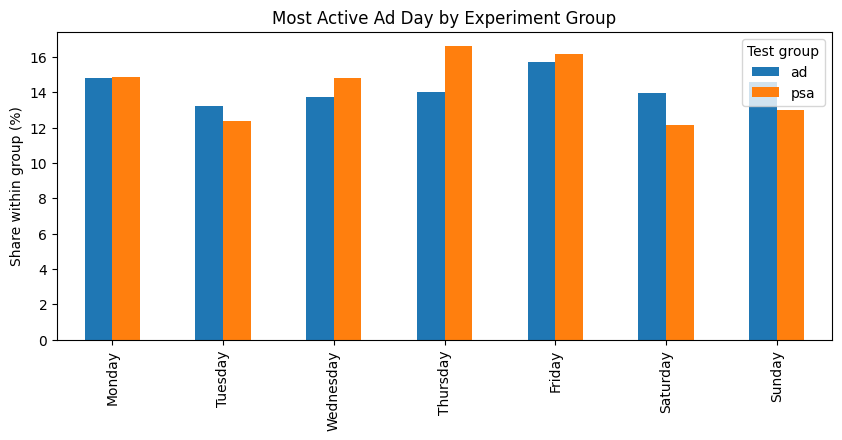

In [113]:
day_by_group.loc[
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
].plot(kind="bar", figsize=(10, 4))

plt.title("Most Active Ad Day by Experiment Group")
plt.xlabel("")
plt.ylabel("Share within group (%)")
plt.legend(title="Test group")
plt.show()

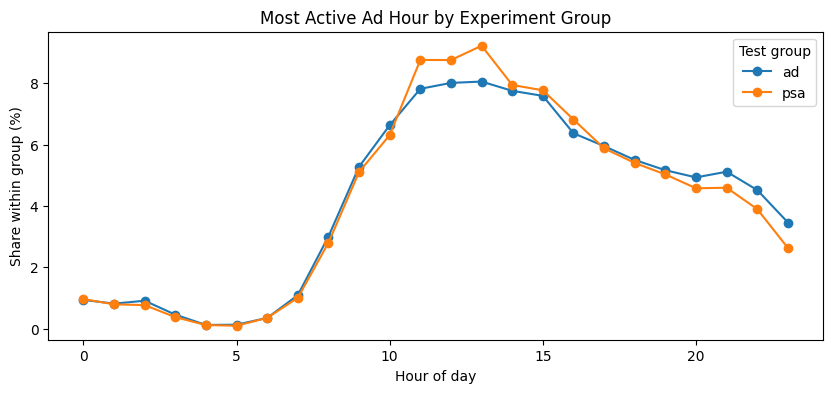

In [114]:
hour_by_group.sort_index().plot(kind="line", marker="o", figsize=(10, 4))

plt.title("Most Active Ad Hour by Experiment Group")
plt.xlabel("Hour of day")
plt.ylabel("Share within group (%)")
plt.legend(title="Test group")
plt.show()

The available day and hour variables describe observed campaign-delivery context. They are compared descriptively but are not treated as verified pre-treatment covariates or as proof of successful randomisation.

In [115]:
conversion_check = (
    df.groupby("test_group", observed=True)["converted"]
    .agg(
        users="size",
        conversions="sum",
        conversion_rate="mean"
    )
    .assign(conversion_rate_pct=lambda x: x["conversion_rate"] * 100)
)

conversion_check

,users,conversions,conversion_rate,conversion_rate_pct
test_group,,,,
ad,564577,14423,0.025547,2.554656
psa,23524,420,0.017854,1.785411


In [116]:
df["total_ads"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

count    588101.000000
mean         24.820876
std          43.715181
min           1.000000
1%            1.000000
5%            1.000000
25%           4.000000
50%          13.000000
75%          27.000000
95%          88.000000
99%         202.000000
max        2065.000000
Name: total_ads, dtype: float64

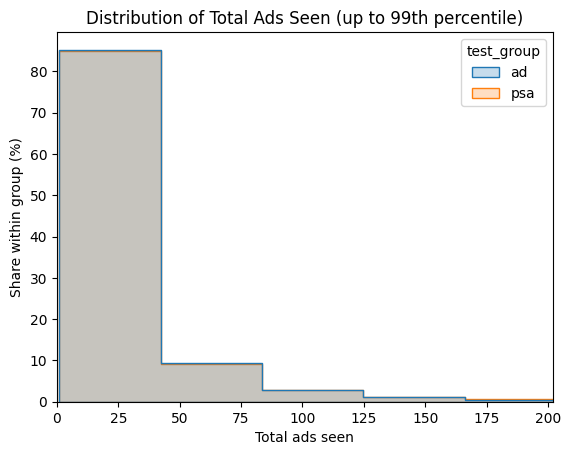

In [117]:
sns.histplot(
    data=df,
    x="total_ads",
    hue="test_group",
    bins=50,
    stat="percent",
    common_norm=False,
    element="step"
)

plt.xlim(0, df["total_ads"].quantile(0.99))
plt.title("Distribution of Total Ads Seen (up to 99th percentile)")
plt.xlabel("Total ads seen")
plt.ylabel("Share within group (%)")
plt.show()

## Experiment check summary

- The extract contains one record per user ID and no duplicate assignments.
- Treatment labels are limited to the documented `ad` and `psa` groups.
- The primary outcome is available and binary for all analysed records.
- No missing or invalid values were identified in the variables used for
  the primary comparison.
- The observed allocation is strongly asymmetric. As the planned allocation
  ratio is unavailable, no formal sample-ratio-mismatch assessment is possible.
- Available day, hour, and exposure fields were reviewed descriptively.
  They cannot verify randomisation because their temporal relationship to
  treatment assignment is not documented.
- The data are suitable for a descriptive two-group comparison of recorded
  conversion. Causal interpretation remains conditional on valid original
  random assignment.

## Not verifiable — Why

- **Random assignment**  
  - No assignment logic / hashing information available  
  - Expected 50:50 or 90:10 split not documented  
  - No planned allocation documented  

- **Test duration and full weekly cycles**  
  - No dates provided  
  - No parallel tests documented  
  - No experiment metadata available  

- **Uniform variant representation**  
  - No access to ad / PSA assets  

- **Conversion window**  
  - No event timestamps available  

- **Guardrail metrics**  
  - No data on costs, complaints, retention, etc.  

- **A priori power or stopping rule**  
  - No test planning documentation available  

## Save data

In [118]:
# save cleaned data to a new CSV file
df.to_csv('../01_data/02_processed/marketing_AB_cleaned.csv', index=False)